#  Cats vs Dogs Classification – Complete Demo
## HOG vs CNN Features + SVM + Visualizations

This notebook demonstrates:
- HOG feature extraction + visualization
- CNN (ResNet18) feature extraction
- Grad-CAM visualization
- Saving features to CSV
- SVM training
- Confusion matrix
- ROC curve
- Performance comparison

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
import seaborn as sns
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
%matplotlib inline

## Dataset Structure
```
dataset/
   cats/
   dogs/
```

In [6]:
data_dir = r"C:\Users\aqii_1\OneDrive\Desktop\catsanddog\data_dir"

## 1️⃣ HOG Feature Extraction + Visualization

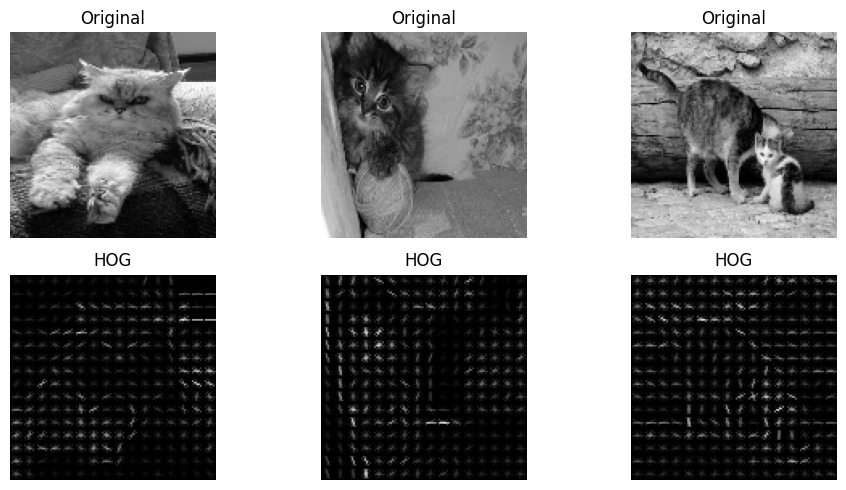

In [7]:
hog_features = []
hog_labels = []
plt.figure(figsize=(10,5))
display_count = 0

for label in os.listdir(data_dir):
    for file in os.listdir(os.path.join(data_dir, label)):
        img_path = os.path.join(data_dir, label, file)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (128,128))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        features, hog_img = hog(gray, orientations=9,
                                pixels_per_cell=(8,8),
                                cells_per_block=(2,2),
                                visualize=True)
        hog_features.append(features)
        hog_labels.append(label)

        if display_count < 3:
            plt.subplot(2,3,display_count+1)
            plt.imshow(gray, cmap='gray')
            plt.title('Original')
            plt.axis('off')
            plt.subplot(2,3,display_count+4)
            plt.imshow(hog_img, cmap='gray')
            plt.title('HOG')
            plt.axis('off')
            display_count += 1

plt.tight_layout()
plt.show()

In [8]:
hog_df = pd.DataFrame(hog_features)
hog_df['label'] = hog_labels
hog_df.to_csv('hog_features.csv', index=False)
hog_df.head()

,0,1,2,3,4,5,6,7,8,9,...,8091,8092,8093,8094,8095,8096,8097,8098,8099,label
0,0.232890,0.029455,0.014654,0.050540,0.232890,0.148066,0.232890,0.223534,0.103932,0.232890,...,0.135277,0.020323,0.014708,0.037485,0.212677,0.230901,0.217765,0.232892,0.101774,cats
1,0.184531,0.120797,0.042908,0.020283,0.094082,0.012213,0.038140,0.299736,0.289959,0.299736,...,0.240499,0.008819,0.027793,0.178359,0.240499,0.210615,0.139915,0.052861,0.179256,cats
2,0.215863,0.116702,0.215863,0.039582,0.166787,0.180020,0.123699,0.179930,0.120293,0.215863,...,0.153993,0.053172,0.063913,0.159540,0.235920,0.146333,0.235920,0.178337,0.029683,cats
3,0.240538,0.123223,0.151312,0.093889,0.240538,0.076708,0.086409,0.035501,0.149194,0.240538,...,0.061727,0.039321,0.116754,0.204814,0.143895,0.040387,0.036033,0.103453,0.039072,cats
4,0.029947,0.000000,0.000000,0.023260,0.204212,0.178336,0.176520,0.023014,0.000000,0.330386,...,0.267941,0.201114,0.143560,0.118848,0.223232,0.071309,0.165365,0.000000,0.134461,cats


## Train SVM on HOG Features

In [9]:
X = hog_df.drop('label', axis=1).values
y = hog_df['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

svm_hog = SVC(kernel='rbf', probability=True)
svm_hog.fit(X_train, y_train)

y_pred = svm_hog.predict(X_test)
print('HOG Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

HOG Accuracy: 0.9912323429128105
              precision    recall  f1-score   support

        cats       0.99      1.00      1.00      2035
        dogs       0.00      0.00      0.00        18

    accuracy                           0.99      2053
   macro avg       0.50      0.50      0.50      2053
weighted avg       0.98      0.99      0.99      2053



c:\Users\meh_o\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\meh_o\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\meh_o\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

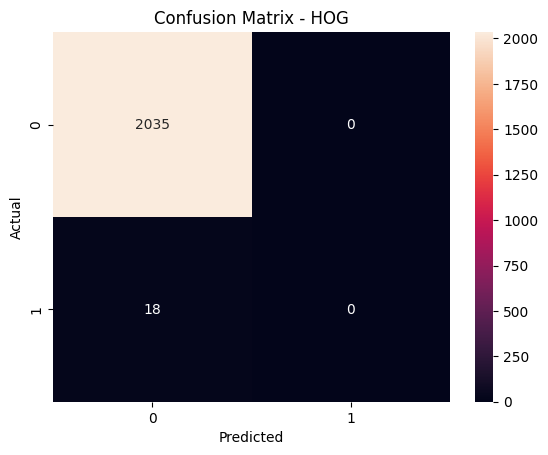

In [10]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix - HOG')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

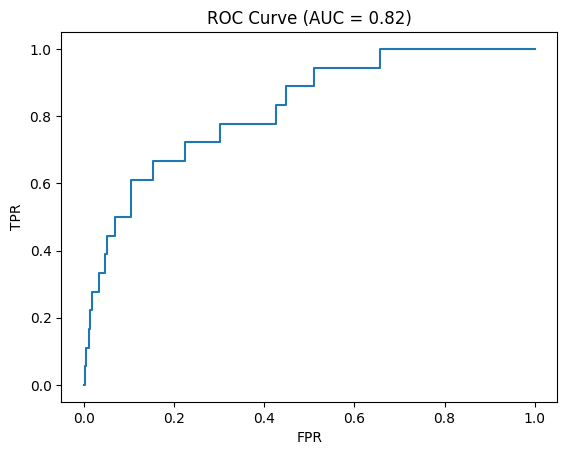

In [11]:
y_prob = svm_hog.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve((y_test=='dogs').astype(int), y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr)
plt.title(f'ROC Curve (AUC = {roc_auc:.2f})')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()

## 2️⃣ CNN Feature Extraction (ResNet18)

In [12]:
model = models.resnet18(pretrained=True)
model = torch.nn.Sequential(*list(model.children())[:-1])
model.eval()

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

dataset = ImageFolder(data_dir, transform=transform)
loader = DataLoader(dataset, batch_size=32, shuffle=False)

cnn_features = []
cnn_labels = []

with torch.no_grad():
    for imgs, lbls in loader:
        output = model(imgs)
        output = output.view(output.size(0), -1)
        cnn_features.append(output.numpy())
        cnn_labels.append(lbls.numpy())

X_cnn = np.vstack(cnn_features)
y_cnn = np.hstack(cnn_labels)

c:\Users\meh_o\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\meh_o\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [13]:
X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_cnn, y_cnn, test_size=0.2, random_state=42)

svm_cnn = SVC(kernel='rbf')
svm_cnn.fit(X_train_cnn, y_train_cnn)

y_pred_cnn = svm_cnn.predict(X_test_cnn)
print('CNN Feature Accuracy:', accuracy_score(y_test_cnn, y_pred_cnn))

CNN Feature Accuracy: 0.997564539698003


## 3️⃣ Performance Comparison

In [14]:
print('HOG Accuracy:', accuracy_score(y_test, y_pred))
print('CNN Accuracy:', accuracy_score(y_test_cnn, y_pred_cnn))

HOG Accuracy: 0.9912323429128105
CNN Accuracy: 0.997564539698003
